In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

In [43]:
# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 10)

In [44]:
# Load data
df = pd.read_csv('C:\\Users\\Lenovo\\Downloads\\Advertising Budget and Sales.csv', index_col=0)
print("LINEAR REGRESSION ANALYSIS: ADVERTISING BUDGET vs SALES")

LINEAR REGRESSION ANALYSIS: ADVERTISING BUDGET vs SALES


In [45]:
# Data Overview
print("\n DATASET OVERVIEW")
print(f"Total Samples: {len(df)}")
print(f"\nFirst few rows:")
print(df.head())
print(f"\nDataset Statistics:")
print(df.describe())


 DATASET OVERVIEW
Total Samples: 200

First few rows:
   TV Ad Budget ($)  Radio Ad Budget ($)  Newspaper Ad Budget ($)  Sales ($)
1             230.1                 37.8                     69.2       22.1
2              44.5                 39.3                     45.1       10.4
3              17.2                 45.9                     69.3        9.3
4             151.5                 41.3                     58.5       18.5
5             180.8                 10.8                     58.4       12.9

Dataset Statistics:
       TV Ad Budget ($)  Radio Ad Budget ($)  Newspaper Ad Budget ($)  \
count        200.000000           200.000000               200.000000   
mean         147.042500            23.264000                30.554000   
std           85.854236            14.846809                21.778621   
min            0.700000             0.000000                 0.300000   
25%           74.375000             9.975000                12.750000   
50%          149.750000 

In [46]:
# For this analysis, I have focued on TV Ad Budget as the primary predictor
X = df[['TV Ad Budget ($)']].values
y = df['Sales ($)'].values

In [47]:
# Build the model
model = LinearRegression()
model.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [48]:
# Predictions
y_pred = model.predict(X)

In [49]:
# Calculate metrics
r2 = r2_score(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))
mae = mean_absolute_error(y, y_pred)
slope = model.coef_[0]
intercept = model.intercept_


In [50]:
# Statistical significance
correlation = np.corrcoef(X.flatten(), y)[0, 1]
print("MODEL RESULTS")
print(f"\n Regression Equation:")
print(f"   Sales = {intercept:.4f} + {slope:.4f} × TV Ad Budget")
print(f"\n Model Performance Metrics:")
print(f"   R² Score: {r2:.4f} ({r2*100:.2f}% variance explained)")
print(f"   RMSE: ${rmse:.4f} million")
print(f"   MAE: ${mae:.4f} million")
print(f"   Correlation: {correlation:.4f}")
print(f"\n Interpretation:")
print(f"   • For every $1M increase in TV ad budget, sales increase by ${slope:.4f}M")
print(f"   • Baseline sales (intercept): ${intercept:.4f}M")

MODEL RESULTS

 Regression Equation:
   Sales = 7.0326 + 0.0475 × TV Ad Budget

 Model Performance Metrics:
   R² Score: 0.6119 (61.19% variance explained)
   RMSE: $3.2423 million
   MAE: $2.5498 million
   Correlation: 0.7822

 Interpretation:
   • For every $1M increase in TV ad budget, sales increase by $0.0475M
   • Baseline sales (intercept): $7.0326M


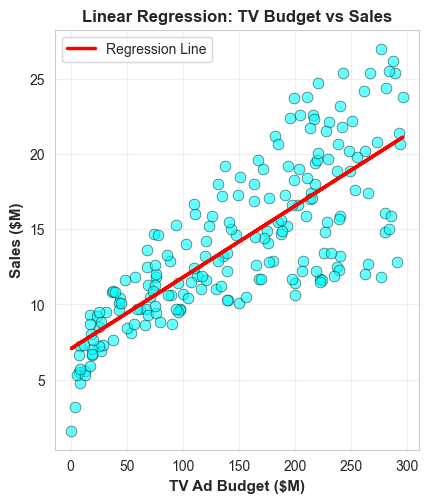

In [51]:
# Create comprehensive visualizations
fig = plt.figure(figsize=(16, 12))

# 1. Scatter plot with regression line
ax1 = plt.subplot(2, 3, 1)
ax1.scatter(X, y, alpha=0.6, color='cyan', s=60, edgecolors='black', linewidth=0.5)
ax1.plot(X, y_pred, color='red', linewidth=2.5, label='Regression Line')
ax1.set_xlabel('TV Ad Budget ($M)', fontsize=11, fontweight='bold')
ax1.set_ylabel('Sales ($M)', fontsize=11, fontweight='bold')
ax1.set_title('Linear Regression: TV Budget vs Sales', fontsize=12, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(alpha=0.3)

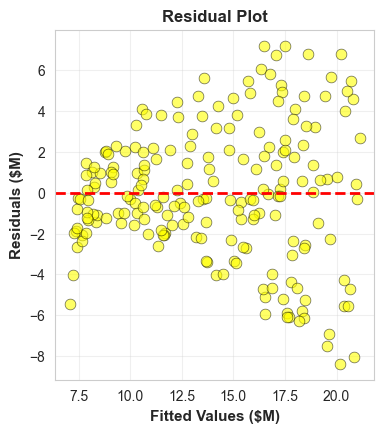

In [52]:
# 2. Residuals plot
ax2 = plt.subplot(2, 3, 2)
residuals = y - y_pred
ax2.scatter(y_pred, residuals, alpha=0.6, color='yellow', s=60, edgecolors='black', linewidth=0.5)
ax2.axhline(y=0, color='red', linestyle='--', linewidth=2)
ax2.set_xlabel('Fitted Values ($M)', fontsize=11, fontweight='bold')
ax2.set_ylabel('Residuals ($M)', fontsize=11, fontweight='bold')
ax2.set_title('Residual Plot', fontsize=12, fontweight='bold')
ax2.grid(alpha=0.3)

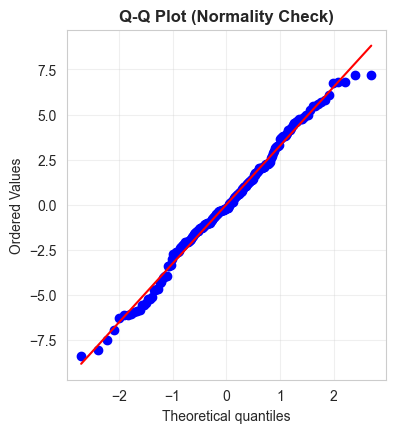

In [53]:
# 3. Q-Q Plot
ax3 = plt.subplot(2, 3, 3)
stats.probplot(residuals, dist="norm", plot=ax3)
ax3.set_title('Q-Q Plot (Normality Check)', fontsize=12, fontweight='bold')
ax3.grid(alpha=0.3)

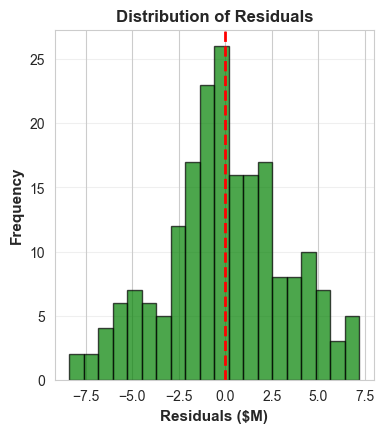

In [54]:
# 4. Histogram of residuals
ax4 = plt.subplot(2, 3, 4)
ax4.hist(residuals, bins=20, color='green', alpha=0.7, edgecolor='black')
ax4.set_xlabel('Residuals ($M)', fontsize=11, fontweight='bold')
ax4.set_ylabel('Frequency', fontsize=11, fontweight='bold')
ax4.set_title('Distribution of Residuals', fontsize=12, fontweight='bold')
ax4.axvline(x=0, color='red', linestyle='--', linewidth=2)
ax4.grid(alpha=0.3, axis='y')

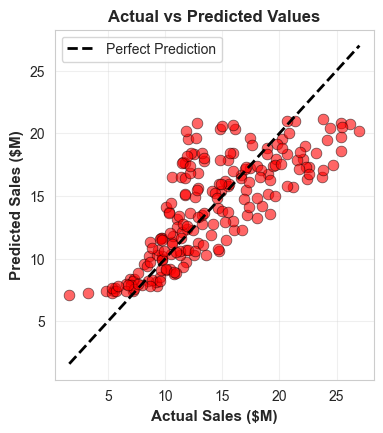

In [55]:
# 5. Actual vs Predicted
ax5 = plt.subplot(2, 3, 5)
ax5.scatter(y, y_pred, alpha=0.6, color='red', s=60, edgecolors='black', linewidth=0.5)
ax5.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', linewidth=2, label='Perfect Prediction')
ax5.set_xlabel('Actual Sales ($M)', fontsize=11, fontweight='bold')
ax5.set_ylabel('Predicted Sales ($M)', fontsize=11, fontweight='bold')
ax5.set_title('Actual vs Predicted Values', fontsize=12, fontweight='bold')
ax5.legend(fontsize=10)
ax5.grid(alpha=0.3)

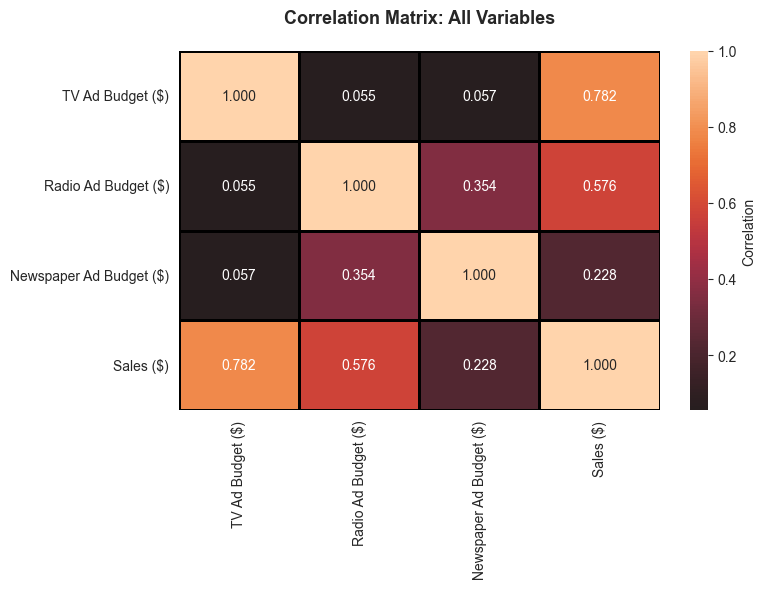

In [56]:
# Correlation heatmap
fig2, ax = plt.subplots(figsize=(8, 6))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.3f',  center=0, 
            cbar_kws={'label': 'Correlation'}, ax=ax, linewidths=1, linecolor='black')
ax.set_title('Correlation Matrix: All Variables', fontsize=13, fontweight='bold', pad=20)
plt.tight_layout()